### Current approach

I separate the data into in train and test before the PCA.

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from hmmlearn import hmm
from hmmlearn.hmm import GaussianHMM
import plotly.express as px
import mlflow
from mlflow.models.signature import infer_signature

In [2]:
files = ['two_class_raw_1s_no.csv', 'two_class_raw_1s_yo_0.5.csv', 'two_class_raw_1s_yo_0.8.csv', 'two_class_raw_2s_no.csv', 'two_class_raw_2s_yo_0.5.csv', 'two_class_raw_2s_yo_0.8.csv', 
        'two_class_raw_3s_no.csv', 'two_class_raw_3s_yo_0.5.csv', 'two_class_raw_3s_yo_0.8.csv', 'two_class_raw_4s_no.csv', 'two_class_raw_4s_yo_0.5.csv', 'two_class_raw_4s_yo_0.8.csv',
        'two_class_raw_5s_no.csv', 'two_class_raw_5s_yo_0.5.csv', 'two_class_raw_5s_yo_0.8.csv']

base_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/'

In [3]:
# data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/two_class_raw_5s_yo_0.8.csv'
# features = pd.read_csv(data_path)
# features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
# features


In [4]:
# plt.figure()
# ax = sns.countplot(x='label',
#                    data=features,
#                    order=features.label.value_counts().index)

# # Manually add value labels
# for i, bar in enumerate(ax.patches):
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 10,
#             f'{int(height)}',
#             ha='center', va='bottom')

# plt.title('Class distribution')
# plt.show()

In [5]:
def setup_xgboost_with_imbalance_handling(X_train, y_train, use_smote=False, original_scale_weight=1.27):
    """
    Set up XGBoost with appropriate imbalance handling
    """
    if use_smote:
        print("Applying SMOTE...")
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
        
        # Check if we still need scale_pos_weight
        unique, counts = np.unique(y_balanced, return_counts=True)
        ratio = counts[0] / counts[1]
        
        if abs(ratio - 1.0) > 0.1:
            scale_weight = ratio
            print(f"Post-SMOTE imbalance detected, using scale_pos_weight: {scale_weight:.3f}")
        else:
            scale_weight = None
            print("Classes balanced after SMOTE, not using scale_pos_weight")
    else:
        print("No SMOTE applied, using original scale_pos_weight")
        X_balanced, y_balanced = X_train, y_train
        scale_weight = original_scale_weight
    
    # Configure XGBoost
    xgb_params = {        
        'n_estimators':200,
        'max_depth':5,
        'learning_rate':0.1,
        'subsample':0.8,
        'colsample_bytree':0.8,
        'random_state':42,
        'eval_metric':'logloss',
        'reg_alpha':0.1,   # L1 regularization
        'reg_lambda':1.0,  # L2 regularization
        'verbosity':0
    }
    
    if scale_weight is not None:
        xgb_params['scale_pos_weight'] = scale_weight
        
        

    
    model = XGBClassifier(**xgb_params)
    
    return model, X_balanced, y_balanced, xgb_params

In [6]:
import mlflow
import mlflow.xgboost
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import os

def log_experiment_run(
    model,
    X_test,
    report_dict,
    loss_fig_path,
    cm_fig_path,
    data_path,
    params,
    experiment_name="With PCA - 88",
    model_name="XGBoost"
):

    # Set experiment
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(experiment_name)

    run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap"
    # run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap_{params.get('smote')}" # with smote
    
    del params['window_size']
    del params['overlap']
    # del params['smote']

    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_params(params)

        # Extract individual class metrics (you can rename 'void' and 'non-void' if your class names are different)
        accuracy = report_dict.get("accuracy", 0.0)
        precision_void = report_dict.get("void", {}).get("precision", 0.0)
        recall_void = report_dict.get("void", {}).get("recall", 0.0)
        f1_void = report_dict.get("void", {}).get("f1-score", 0.0)

        precision_non_void = report_dict.get("non-void", {}).get("precision", 0.0)
        recall_non_void = report_dict.get("non-void", {}).get("recall", 0.0)
        f1_non_void = report_dict.get("non-void", {}).get("f1-score", 0.0)
        
        mlflow.log_metrics({

            # Void class (e.g., posture change)
            "precision_void": precision_void,
            "recall_void": recall_void,
            "f1_void": f1_void,

            # Non-void class
            "precision_non_void": precision_non_void,
            "recall_non_void": recall_non_void,
            "f1_non_void": f1_non_void,
            "accuracy": accuracy
        })

        # Log model with signature
        # input_example = X_test.iloc[:1]
        input_example = X_test[:1]
        signature = infer_signature(X_test, model.predict(X_test))

        try:
            mlflow.xgboost.log_model(
                xgb_model=model,
                artifact_path=model_name,
                input_example=input_example,
                signature=signature
            )
        except Exception as e:
            print("Error logging model:", e)
        
        # try:
        #     mlflow.log_artifact(cm_fig_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)
            
        # try:
        #     mlflow.log_artifact(loss_fig_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)
        
        # try:    
        #     mlflow.log_artifact(data_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)

No SMOTE applied, using original scale_pos_weight
Classification report for 1s_no
              precision    recall  f1-score   support

    non-void       0.74      0.78      0.76       396
        void       0.61      0.56      0.58       246

    accuracy                           0.69       642
   macro avg       0.67      0.67      0.67       642
weighted avg       0.69      0.69      0.69       642



KeyboardInterrupt: 

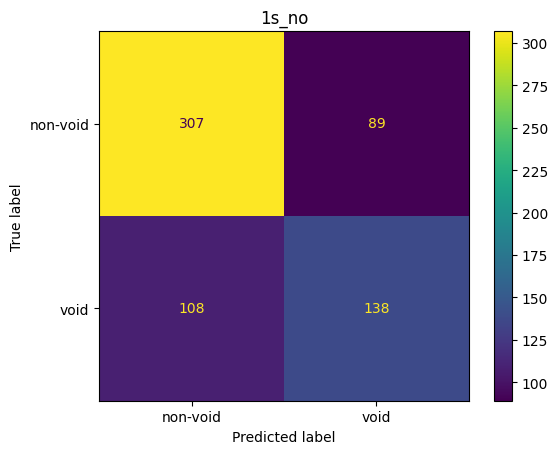

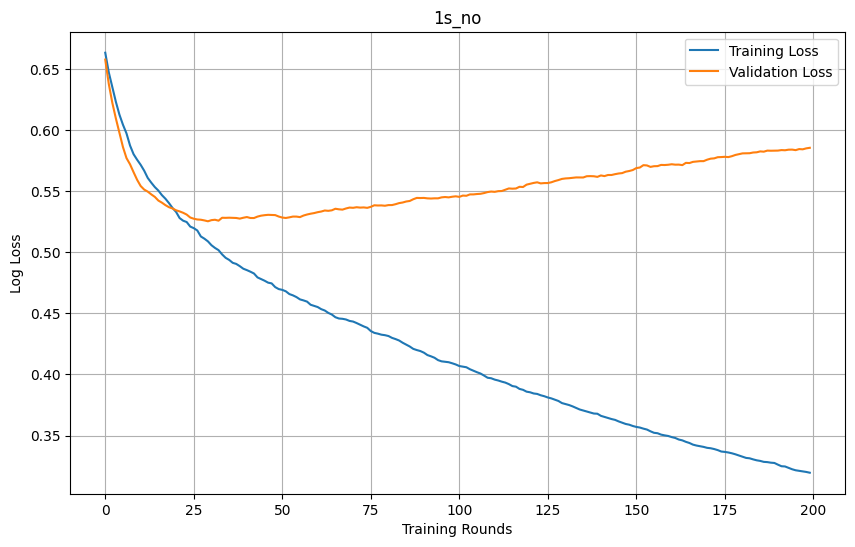

In [7]:
results = []
for file in files:
    data_path = os.path.join(base_path, file)
    features = pd.read_csv(data_path)
    features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
    details = file.split('_')
    exp_name = f"{details[3]}_{details[-1].replace('.csv', '')}"
    
    # split data
    X = features.drop(columns=['label', 'experiment_id'])
    y = features['label']
    groups = features['experiment_id']

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]
    
    # PCA
    scaler = StandardScaler()
    pca = PCA()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    pca.fit(X_train_scaled)
    
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
    
    pca_final = PCA(n_components=3)
    X_train_pca = pca_final.fit_transform(X_train_scaled)
    X_test_pca = pca_final.transform(X_test_scaled)
    
    model, X_train_final, y_train_final, params = setup_xgboost_with_imbalance_handling(
                                        X_train_pca, 
                                        y_train,
                                        use_smote=False,  # Switch this as needed
                                        original_scale_weight=1.27
                                    )
    
    label_encoder = LabelEncoder()
    # Encode y_test and y_train
    y_train_encoded = label_encoder.fit_transform(y_train_final) 
    y_test_encoded = label_encoder.transform(y_test)
    
    eval_set = [(X_train_final, y_train_encoded), (X_test_pca, y_test_encoded)]
    model.fit(X_train_final, y_train_encoded, eval_set=eval_set, verbose=False)
    
    # Classification report
    preds = model.predict(X_test_pca)
    y_pred = label_encoder.inverse_transform(preds)
    y_pred_prob = model.predict_proba(X_test_pca)
    y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
    report = classification_report(y_test, y_pred)
    print(f"Classification report for {exp_name}")
    print("============================================")
    print(report)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
    cm_display.plot()
    plt.title(f"{exp_name}")
    cm_fig_path = f'/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/model_plots/xgboost/original_features/with_pca/cm_{exp_name}.png'
    plt.savefig(cm_fig_path)

    
    # Retrieve the evaluation results
    results = model.evals_result()
    train_loss = results['validation_0']['logloss']
    test_loss = results['validation_1']['logloss']

    # Plot the loss function
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(test_loss, label='Validation Loss')
    plt.xlabel('Training Rounds')
    plt.ylabel('Log Loss')
    plt.title(f'{exp_name}')
    plt.legend()
    plt.grid(True)
    loss_fig_path = f'/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/model_plots/xgboost/original_features/with_pca/loss_{exp_name}.png'
    plt.savefig(loss_fig_path)
    

    

    overlap = details[-1].replace('.csv', '')
    win_size = int(details[3].split('s')[0])
    overlap = float(overlap if overlap != 'no' else 0.0)
    
    # Example parameters    
    params['window_size'] = win_size
    params['overlap'] = overlap
    # params['smote'] = 'smote'
    params['exp_name'] = exp_name


    # y_pred = model.predict(X_test)
    report_dict = classification_report(y_test, y_pred, output_dict=True)

    log_experiment_run(model, X_test_pca, report_dict, cm_fig_path, data_path, loss_fig_path, params)

View label distribution

In [ ]:
# X = features.drop(columns=['label', 'experiment_id'])
# y = features['label']
# groups = features['experiment_id']

# splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
# train_idx, test_idx = next(splitter.split(X, y, groups))

# X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
# y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

Scale and fit on training data only

In [ ]:
# scaler = StandardScaler()
# pca = PCA()

In [ ]:
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# pca.fit(X_train_scaled)

Transform both train and test using the same fitted PCA

In [ ]:
# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
# n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1


In [ ]:
# pca_final = PCA(n_components=3)
# X_train_pca = pca_final.fit_transform(X_train_scaled)
# X_test_pca = pca_final.transform(X_test_scaled)



In [ ]:
# def setup_xgboost_with_imbalance_handling(X_train, y_train, use_smote=False, original_scale_weight=1.27):
#     """
#     Set up XGBoost with appropriate imbalance handling
#     """
#     if use_smote:
#         print("Applying SMOTE...")
#         smote = SMOTE(random_state=42)
#         X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
        
#         # Check if we still need scale_pos_weight
#         unique, counts = np.unique(y_balanced, return_counts=True)
#         ratio = counts[0] / counts[1]
        
#         if abs(ratio - 1.0) > 0.1:
#             scale_weight = ratio
#             print(f"Post-SMOTE imbalance detected, using scale_pos_weight: {scale_weight:.3f}")
#         else:
#             scale_weight = None
#             print("Classes balanced after SMOTE, not using scale_pos_weight")
#     else:
#         print("No SMOTE applied, using original scale_pos_weight")
#         X_balanced, y_balanced = X_train, y_train
#         scale_weight = original_scale_weight
    
#     # Configure XGBoost
#     xgb_params = {        
#         'n_estimators':200,
#         'max_depth':5,
#         'learning_rate':0.1,
#         'subsample':0.8,
#         'colsample_bytree':0.8,
#         'random_state':42,
#         'eval_metric':'logloss',
#         'reg_alpha':0.1,   # L1 regularization
#         'reg_lambda':1.0,  # L2 regularization
#         'verbosity':0
#     }
    
#     if scale_weight is not None:
#         xgb_params['scale_pos_weight'] = scale_weight
        
        

    
#     model = XGBClassifier(**xgb_params)
    
#     return model, X_balanced, y_balanced, xgb_params

In [ ]:
model, X_train_final, y_train_final, params = setup_xgboost_with_imbalance_handling(
                                        X_train_pca, 
                                        y_train,
                                        use_smote=True,  # Switch this as needed
                                        original_scale_weight=1.27
                                    )

In [ ]:
label_encoder = LabelEncoder()
# Encode y_test and y_train
y_train_encoded = label_encoder.fit_transform(y_train_final) 
y_test_encoded = label_encoder.transform(y_test)

In [ ]:
eval_set = [(X_train_final, y_train_encoded), (X_test_pca, y_test_encoded)]
model.fit(X_train_final, y_train_encoded, eval_set=eval_set, verbose=False)

In [ ]:
# Classification report
preds = model.predict(X_test_pca)
y_pred = label_encoder.inverse_transform(preds)
y_pred_prob = model.predict_proba(X_test_pca)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
report = classification_report(y_test, y_pred)

print(report)

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
cm_display.plot()
plt.title('1s sliding window, no overlap, smote')
cm_fig_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/model_plots/xgboost/default_params/original_features/with_pca_smote'
# plt.savefig(cm_fig_path)
plt.show()


In [ ]:
# Retrieve the evaluation results
results = model.evals_result()
train_loss = results['validation_0']['logloss']
test_loss = results['validation_1']['logloss']

# Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Training Rounds')
plt.ylabel('Log Loss')
plt.title('1s sliding window, no overlap, smote')
plt.legend()
plt.grid(True)
loss_fig_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/model_plots/xgboost/default_params/original_features/with_pca_smote'
# plt.savefig(loss_fig_path)
plt.show()

In [ ]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_dict

## Upload to MLFlow

In [ ]:
import mlflow
from mlflow.models.signature import infer_signature

In [ ]:
import mlflow
import mlflow.xgboost
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import os

def log_experiment_run(
    model,
    X_test,
    report_dict,
    loss_fig_path,
    cm_fig_path,
    data_path,
    params,
    experiment_name="With PCA and smote",
    model_name="XGBoost"
):

    # Set experiment
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(experiment_name)

    run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap"
    # run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap_{params.get('smote')}" # with smote
    
    del params['window_size']
    del params['overlap']

    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_params(params)

        
        mlflow.log_metrics({
            "accuracy": report_dict.get("accuracy", 0.0),
            "recall_non_void": report_dict.get("non-void", {}).get("recall", 0.0),
            "recall_void": report_dict.get("void", {}).get("recall", 0.0),
            "f1_score_macro": report_dict.get("macro avg", {}).get("f1-score", 0.0)
        })

        # Log model with signature
        # input_example = X_test.iloc[:1]
        input_example = X_test[:1]
        signature = infer_signature(X_test, model.predict(X_test))

        try:
            mlflow.xgboost.log_model(
                xgb_model=model,
                artifact_path=model_name,
                input_example=input_example,
                signature=signature
            )
        except Exception as e:
            print("Error logging model:", e)
        
        # try:
        #     mlflow.log_artifact(cm_fig_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)
            
        # try:
        #     mlflow.log_artifact(loss_fig_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)
        
        # try:    
        #     mlflow.log_artifact(data_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)


In [ ]:
from sklearn.metrics import classification_report

# # Example parameters
# params['window_size'] = 5
# params['overlap'] = 0.8
# params['smote'] = 'smote'
# params['exp_name'] = '5s_0.8_overlap'


# # y_pred = model.predict(X_test)
# report_dict = classification_report(y_test, y_pred, output_dict=True)

# log_experiment_run(model, X_test_pca, report_dict, cm_fig_path, data_path, loss_fig_path, params)

In [ ]:
# y_pred

## Prepare data for state space classification

In [ ]:
data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/three_class_raw_2s_yo_0.8.csv'
three_class_features = pd.read_csv(data_path)
three_class_features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)

Get labels of three class data

In [ ]:
y_three_class = three_class_features['label']
y_3 = y_three_class.iloc[test_idx]


Probability output of XGBoost predictions 

In [ ]:
y_pred_prob = model.predict_proba(X_test_pca)[:, 1]


Experiment ids of test set

In [ ]:
exp_id = features['experiment_id'].iloc[test_idx]
test_experiment_ids = exp_id.unique()

In [ ]:
# y_pred

In [ ]:
# y_test_encoded

In [ ]:
df = pd.DataFrame({
    'exp_id': exp_id,
    'three_class_label': y_3,
    'two_class_label': y_test,
    'two_class_pred': y_pred,
    'two_class_pred_num': preds,
    'two_class_pred_prob': y_pred_prob
})

df.head()

In [ ]:
df.to_csv('output/outputs.csv', index=False)

## State space classification

In [ ]:
def state_space_classifier(arr, window=7):  
    state_preds = []  
    state = 'pre-void'
    terminated = False
    arr_length = len(arr)
    
    i = 0
    while i < arr_length:
        if terminated:
            state_preds.append('post-void')
            i += 1
            continue
        
        if state == 'pre-void':
            if i + window <= arr_length and all(x == 1 for x in arr[i:i+window]):
                state = 'void'
                state_preds.append(state)
                i += 1
                continue
                
        elif state == 'void':
            if i + window <= arr_length and all(x == 0 for x in arr[i:i+window]):
                state = 'post-void'
                terminated = True
                state_preds.append(state)
                i += 1
                continue
        
        state_preds.append(state)
        i += 1
    
    return state_preds

In [ ]:
def state_space_classifier_prob(prob_arr, 
                        void_entry_threshold=0.5, 
                        void_exit_threshold=0.1,
                        entry_window=5,
                        exit_window=7,
                        min_consecutive_ratio=0.8):
    """
    State-based classifier using XGBoost probability outputs
    
    Parameters:
    - prob_arr: Array of P(void) probabilities from XGBoost
    - void_entry_threshold: Probability threshold to enter void state
    - void_exit_threshold: Probability threshold to exit void state  
    - entry_window: Window size for entering void state
    - exit_window: Window size for exiting void state
    - min_consecutive_ratio: Minimum ratio of window that must meet threshold
    """
    
    state_preds = []
    state = 'pre-void'
    terminated = False
    arr_length = len(prob_arr)
    
    i = 0
    while i < arr_length:
        if terminated:
            state_preds.append('post-void')
            i += 1
            continue
        
        if state == 'pre-void':
            # Check if we have enough values for entry window
            if i + entry_window <= arr_length:
                window_probs = prob_arr[i:i+entry_window]
                
                # Check if enough of the window meets void threshold
                above_threshold = np.sum(window_probs >= void_entry_threshold)
                if above_threshold >= (entry_window * min_consecutive_ratio):
                    # Additional check: window mean should be high
                    if np.mean(window_probs) >= void_entry_threshold:
                        state = 'void'
                        state_preds.append(state)
                        i += 1
                        continue
                        
        elif state == 'void':
            # Check if we have enough values for exit window
            if i + exit_window <= arr_length:
                window_probs = prob_arr[i:i+exit_window]
                
                # Check if enough of the window meets non-void threshold
                below_threshold = np.sum(window_probs <= void_exit_threshold)
                if below_threshold >= (exit_window * min_consecutive_ratio):
                    # Additional check: window mean should be low
                    if np.mean(window_probs) <= void_exit_threshold:
                        state = 'post-void'
                        terminated = True
                        state_preds.append(state)
                        i += 1
                        continue
        
        state_preds.append(state)
        i += 1
    
    return state_preds

In [ ]:
def adaptive_state_classifier(prob_arr, 
                            base_entry_threshold=0.5,
                            base_exit_threshold=0.1,
                            entry_window=5,
                            exit_window=7,
                            confidence_boost=0.1):
    """
    Adaptive version that adjusts thresholds based on recent probability trends
    """
    
    state_preds = []
    state = 'pre-void'
    terminated = False
    arr_length = len(prob_arr)
    
    i = 0
    while i < arr_length:
        if terminated:
            state_preds.append('post-void')
            i += 1
            continue
        
        # Calculate recent trend (last 3 values)
        recent_start = max(0, i-3)
        recent_probs = prob_arr[recent_start:i+1]
        trend = np.mean(np.diff(recent_probs)) if len(recent_probs) > 1 else 0
        
        if state == 'pre-void':
            # Lower threshold if trend is increasing (more confident about void)
            entry_threshold = base_entry_threshold - (confidence_boost if trend > 0 else 0)
            
            if i + entry_window <= arr_length:
                window_probs = prob_arr[i:i+entry_window]
                window_mean = np.mean(window_probs)
                window_std = np.std(window_probs)
                
                # Transition if mean is high and low variance (stable high confidence)
                if (window_mean >= entry_threshold and 
                    window_std < 0.2 and  # Low variance requirement
                    np.min(window_probs) >= entry_threshold - 0.1):  # No big dips
                    
                    state = 'void'
                    state_preds.append(state)
                    i += 1
                    continue
                    
        elif state == 'void':
            # Higher threshold if trend is decreasing (more confident about non-void)
            exit_threshold = base_exit_threshold + (confidence_boost if trend < 0 else 0)
            
            if i + exit_window <= arr_length:
                window_probs = prob_arr[i:i+exit_window]
                window_mean = np.mean(window_probs)
                window_std = np.std(window_probs)
                
                # Transition if mean is low and stable
                if (window_mean <= exit_threshold and 
                    window_std < 0.2 and  # Low variance requirement
                    np.max(window_probs) <= exit_threshold + 0.1):  # No big spikes
                    
                    state = 'post-void'
                    terminated = True
                    state_preds.append(state)
                    i += 1
                    continue
        
        state_preds.append(state)
        i += 1
    
    return state_preds

In [ ]:
def confidence_weighted_classifier(prob_arr, confidence_arr=None, 
                                 void_threshold=0.7, 
                                 non_void_threshold=0.3,
                                 min_confidence=0.6,
                                 window=5):
    """
    Version that incorporates prediction confidence
    confidence_arr: Array of confidence scores (e.g., max probability from predict_proba)
    """
    
    if confidence_arr is None:
        # Use probability distance from 0.5 as confidence proxy
        confidence_arr = np.abs(prob_arr - 0.5) * 2
    
    state_preds = []
    state = 'pre-void'
    terminated = False
    arr_length = len(prob_arr)
    
    i = 0
    while i < arr_length:
        if terminated:
            state_preds.append('post-void')
            i += 1
            continue
        
        if state == 'pre-void':
            if i + window <= arr_length:
                window_probs = prob_arr[i:i+window]
                window_conf = confidence_arr[i:i+window]
                
                # Only consider high-confidence predictions
                high_conf_mask = window_conf >= min_confidence
                if np.sum(high_conf_mask) >= window * 0.6:  # At least 60% high confidence
                    high_conf_probs = window_probs[high_conf_mask]
                    
                    if np.mean(high_conf_probs) >= void_threshold:
                        state = 'void'
                        state_preds.append(state)
                        i += 1
                        continue
                        
        elif state == 'void':
            if i + window <= arr_length:
                window_probs = prob_arr[i:i+window]
                window_conf = confidence_arr[i:i+window]
                
                # Only consider high-confidence predictions
                high_conf_mask = window_conf >= min_confidence
                if np.sum(high_conf_mask) >= window * 0.6:
                    high_conf_probs = window_probs[high_conf_mask]
                    
                    if np.mean(high_conf_probs) <= non_void_threshold:
                        state = 'post-void'
                        terminated = True
                        state_preds.append(state)
                        i += 1
                        continue
        
        state_preds.append(state)
        i += 1
    
    return state_preds

In [ ]:
import numpy as np
from hmmlearn import hmm

def hmm_classifier_with_outputs(acc):
    observations = np.array(acc).reshape(-1, 1)  # Use the predictions from the DataFrame

    # Step 2: Define HMM parameters
    # Hidden states: 0 = pre-void, 1 = void, 2 = post-void
    n_states = 3
    n_observations = 2  # 0 and 1 from XGBoost

    # Transition matrix: left-to-right (no jumping back)
    # Rows = from-state, Cols = to-state
    transmat = np.array([
        [0.8, 0.2, 0.0],  # pre-void
        [0.0, 0.8, 0.2],  # void
        [0.0, 0.0, 1.0]   # post-void (absorbing)
    ])

    # Emission probabilities
    # Each row corresponds to a hidden state:
    # [P(non-void|state), P(void|state)]
    emissionprob = np.array([
        [0.9, 0.1],  # pre-void mostly emits non-void
        [0.2, 0.8],  # void mostly emits void
        [0.8, 0.2]   # post-void mostly emits non-void again
    ])

    # Start probabilities
    startprob = np.array([1.0, 0.0, 0.0])  # always start in pre-void

    # Step 3: Create and apply the model
    model = hmm.CategoricalHMM(
        n_components=n_states,
        init_params="",
        n_iter=10
    )

    model.startprob_ = startprob
    model.transmat_ = transmat
    model.emissionprob_ = emissionprob

    # Step 4: Decode hidden states
    logprob, hidden_states = model.decode(observations, algorithm="viterbi")

    # Step 5: Map numeric states to labels
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    
    return state_sequence

In [ ]:
import numpy as np
from hmmlearn import hmm

def hmm_classifier_with_probs(probs):
    # Step 1: Define observed sequence from XGBoost model
    bins = np.digitize(probs, bins=[0.2, 0.5])
    observations = probs.reshape(-1, 1)  # Use the probabilities from the XGBoost model
    # Step 2: Define HMM parameters
    # Hidden states: 0 = pre-void, 1 = void, 2 = post-void
    n_states = 3
    n_observations = 2  # 0 and 1 from XGBoost

    # Transition matrix: left-to-right (no jumping back)
    # Rows = from-state, Cols = to-state
    transmat = np.array([
        [0.8, 0.2, 0.0],  # pre-void
        [0.0, 0.8, 0.2],  # void
        [0.0, 0.0, 1.0]   # post-void (absorbing)
    ])

    # Emission probabilities
    # Each row corresponds to a hidden state:
    # [P(non-void|state), P(void|state)]
    emissionprob = np.array([
        [0.9, 0.1, 0.0],  # pre-void emits mostly low probability
        [0.1, 0.2, 0.7],  # void emits high probability
        [0.8, 0.2, 0.0]   # post-void emits mostly low probability again
    ])

    # Start probabilities
    startprob = np.array([1.0, 0.0, 0.0])  # always start in pre-void

    # Step 3: Create and apply the model
    model = hmm.CategoricalHMM(
        n_components=n_states,
        init_params="",
        n_iter=10
    )

    model.startprob_ = startprob
    model.transmat_ = transmat
    model.emissionprob_ = emissionprob

    # Step 4: Decode hidden states
    logprob, hidden_states = model.decode(observations, algorithm="viterbi")

    # Step 5: Map numeric states to labels
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    
    return state_sequence

# Output
# print("Binary observations:", observations.ravel().tolist())
# print("Decoded HMM states:", state_sequence)

In [ ]:
def hmm_classifier_with_prob_bins(probs):
    # Step 1: Define observed sequence from XGBoost model
    bins = np.digitize(probs, bins=[0.2, 0.5])
    observations = bins.reshape(-1, 1)  # Use the probabilities from the XGBoost model
    
    # Step 2: Define HMM parameters
    # Hidden states: 0 = pre-void, 1 = void, 2 = post-void
    n_states = 3
    n_observations = 2  # 0 and 1 from XGBoost

    # Transition matrix: left-to-right (no jumping back)
    # Rows = from-state, Cols = to-state
    transmat = np.array([
        [0.8, 0.2, 0.0],  # pre-void
        [0.0, 0.8, 0.2],  # void
        [0.0, 0.0, 1.0]   # post-void (absorbing)
    ])

    # Emission probabilities
    # Each row corresponds to a hidden state:
    # [P(non-void|state), P(void|state)]

    emissionprob = np.array([
        [0.9, 0.1, 0.0],  # pre-void emits mostly low probability
        [0.1, 0.2, 0.7],  # void emits high probability
        [0.8, 0.2, 0.0]   # post-void emits mostly low probability again
    ])

    # Start probabilities
    startprob = np.array([1.0, 0.0, 0.0])  # always start in pre-void

    # Step 3: Create and apply the model
    model = hmm.CategoricalHMM(
        n_components=n_states,
        init_params="",
        n_iter=10
    )

    model.startprob_ = startprob
    model.transmat_ = transmat
    model.emissionprob_ = emissionprob

    # Step 4: Decode hidden states
    logprob, hidden_states = model.decode(observations, algorithm="viterbi")

    # Step 5: Map numeric states to labels
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    
    return state_sequence

In [ ]:
def hmm_classifier_with_probs_gaus(probs):

    obs = probs.reshape(-1, 1)

    # model_hmm = GaussianHMM(n_components=3, covariance_type="full", n_iter=10, init_params="")
    model_hmm = GaussianHMM(n_components=3, covariance_type="full")


    # Set initial parameters or let it learn from unsupervised training
    model_hmm.startprob_ = np.array([1.0, 0.0, 0.0])
    model_hmm.transmat_ = np.array([
        [0.9, 0.1, 0.0],
        [0.0, 0.8, 0.2],
        [0.0, 0.0, 1.0]
    ])

    # Fit to learn emission parameters, or set manually
    model_hmm.fit(obs)  # optional: or fit with constraints
    model_hmm.means_ = np.array([[0.2], [0.8], [0.2]])  # Expected P(void) for each state
    model_hmm.covars_ = np.array([[[0.1]], [[0.1]], [[0.1]]])  # Variance

    # logprob, hidden_states = model_hmm.decode(obs, algorithm="viterbi")
    hidden_states = model_hmm.predict(obs)
    
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    return state_sequence

In [ ]:
def hmm_state_classifier_c(void_probs, n_states=3):
    """
    Use HMM with XGBoost probabilities as observations
    States: 0=pre-void, 1=void, 2=post-void
    """
    
    # Reshape for hmmlearn (needs 2D array)
    observations = void_probs.reshape(-1, 1)
    
    # Create HMM model
    model = hmm.GaussianHMM(n_components=n_states, covariance_type="full")
    
    # Define state transition constraints
    # pre-void -> void -> post-void (mostly forward progression)
    transmat = np.array([
        [0.9, 0.1, 0.0],    # pre-void: mostly stay, can go to void
        [0.0, 0.8, 0.2],    # void: mostly stay, can go to post-void
        [0.0, 0.0, 1.0]     # post-void: terminal state
    ])
    
    model.transmat_ = transmat
    
    # Set initial state probabilities (always start in pre-void)
    model.startprob_ = np.array([1.0, 0.0, 0.0])
    
    # Set emission parameters based on expected probabilities
    # Pre-void: low void probability
    # Void: high void probability  
    # Post-void: low void probability
    model.means_ = np.array([[0.2], [0.5], [0.1]])  # Expected P(void) for each state
    model.covars_ = np.array([[[0.1]], [[0.1]], [[0.1]]])  # Variance
    
    # Predict most likely state sequence
    hidden_states = model.predict(observations)
    
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    return state_sequence

In [ ]:
def custom_hmm_classifier(void_probs, n_bins=5):
    """
    Discretize probabilities and use custom HMM
    """
    
    # Bin probabilities into discrete observations
    bins = np.linspace(0, 1, n_bins + 1)
    observations = np.digitize(void_probs, bins) - 1
    
    transmat = np.array([
        [0.9, 0.1, 0.0],    # pre-void: mostly stay, can go to void
        [0.0, 0.8, 0.2],    # void: mostly stay, can go to post-void
        [0.0, 0.0, 1.0]     # post-void: terminal state
    ])
    
    # Define emission probabilities
    # P(observation | state) for each state
    emission_probs = np.array([
        [0.4, 0.3, 0.2, 0.1, 0.0],  # pre-void: favor low void probs
        [0.0, 0.1, 0.2, 0.3, 0.4],  # void: favor high void probs
        [0.4, 0.3, 0.2, 0.1, 0.0]   # post-void: favor low void probs
    ])
    
    
    # Use Viterbi algorithm to find most likely state sequence
    hidden_states = viterbi_decode(observations, transmat, emission_probs)
    
    
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    return state_sequence

In [ ]:
# probs = y_pred_prob[:,1]  # Probability of being in the 'void' class

In [ ]:
# bins = np.digitize(probs, bins=[0.2, 0.5])  # results in 0, 1, 2


In [ ]:
preds = model.predict(X_test_pca)

In [ ]:
all_preds = []
for exp_id in test_experiment_ids:
    exp_df = df[df['exp_id'] == exp_id]
    # print(exp_df.head(20))
    # exp = exp_df['two_class_pred_num'].values # using raw predictions
    exp = exp_df['two_class_pred_prob'].values  # using probabilities
    # exp_enc = label_encoder.transform(exp)
    # exp_mask = (test_groups == exp_id)
    # exp_preds = test_preds[exp_mask]
    # exp_state_preds = state_space_classifier(exp, window=7)
    exp_state_preds = state_space_classifier_prob(exp)
    # exp_state_preds = adaptive_state_classifier(exp)
    # exp_state_preds = confidence_weighted_classifier(exp)
    # exp_state_preds = hmm_classifier_with_outputs(exp)
    # exp_state_preds = hmm_classifier_with_probs(exp)
    # exp_state_preds = hmm_classifier_with_prob_bins(exp)
    # exp_state_preds = hmm_classifier_with_probs_gaus(exp)
    # exp_state_preds = hmm_state_classifier_c(exp)
    # exp_state_preds = custom_hmm_classifier(exp)
    # print(exp_state_preds)
    all_preds.extend(exp_state_preds)
    # Evaluate this experiment

In [ ]:
target_order = ['pre-void', 'void', 'post-void']
report = classification_report(y_3, all_preds, labels=target_order)

print(report)

In [ ]:
labels = ['pre-void', 'void', 'post-void']

cm = confusion_matrix(y_3, all_preds, labels=labels)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
cm_display.plot()
# plt.title('5s sliding window, 0.8 overlap, smote')
# cm_fig_path = 'model_plots/two_class_results/cm_5s_0.8_smote.png'
# plt.savefig(cm_fig_path)
plt.show()

In [ ]:
print("Accuracy: ", accuracy_score(y_3, all_preds))

In [ ]:
df['three_class_pred'] = all_preds
df.head()

In [ ]:
df.to_csv('output/outputs.csv', index=False)

# Validation

In [ ]:
data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/two_class_val.csv'
features = pd.read_csv(data_path)
features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
features

In [ ]:
X_val = features.drop(columns=['label', 'experiment_id'])
y_val = features['label']

In [ ]:
X_val_scaled = scaler.transform(X_val)

In [ ]:
X_val_pca = pca_final.transform(X_val_scaled)

In [ ]:
preds = model.predict(X_val_pca)
y_pred = label_encoder.inverse_transform(preds)
report = classification_report(y_val, y_pred)

print(report)

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
cm_display.plot()
plt.show()

In [ ]:
exp_id = features['experiment_id']
test_experiment_ids = features['experiment_id'].unique()

In [ ]:
y_pred_prob = model.predict_proba(X_val_pca)[:, 1]

In [ ]:
df_val = pd.DataFrame({
    'exp_id': exp_id,
    # 'three_class_label': y_3,
    'two_class_label': y_val,
    'two_class_pred': y_pred,
    # 'two_class_pred_num': preds,
    'two_class_pred_prob': y_pred_prob
})

In [ ]:
all_preds = []
for exp_id in test_experiment_ids:
    exp_df = df_val[df_val['exp_id'] == exp_id]
    exp = exp_df['two_class_pred_prob'].values  # using probabilities
    # exp_state_preds = state_space_classifier_prob(exp)
    exp_state_preds = hmm_state_classifier_c(exp)
    all_preds.extend(exp_state_preds)
    # Evaluate this experiment

In [ ]:
target_order = ['pre-void', 'void', 'post-void']
report = classification_report(y_val, all_preds, labels=target_order)

print(report)

In [ ]:
labels = ['pre-void', 'void', 'post-void']

cm = confusion_matrix(y_val, all_preds, labels=labels)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
cm_display.plot()
# plt.title('5s sliding window, 0.8 overlap, smote')
# cm_fig_path = 'model_plots/two_class_results/cm_5s_0.8_smote.png'
# plt.savefig(cm_fig_path)
plt.show()

In [ ]:
# labels = ['pre-void', 'void', 'post-void']

# cm = confusion_matrix(y_3, all_preds, labels=labels)
# cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
# cm_display.plot()
# # plt.title('5s sliding window, 0.8 overlap, smote')
# # cm_fig_path = 'model_plots/two_class_results/cm_5s_0.8_smote.png'
# # plt.savefig(cm_fig_path)
# plt.show()

In [ ]:
# # y_pred_prob
# y_pre_prob_arr = np.array(y_pred_prob, dtype=float)
# np.set_printoptions(suppress=True, threshold=np.inf, linewidth=np.inf, precision=8)

# # Now print the array
# print(y_pre_prob_arr)

In [ ]:
# probs = y_pred_prob[:,1]  # Probability of being in the 'void' class
# probs


In [ ]:
# # Train the model
# # model = xgb.XGBClassifier()
# model.fit(X_train_final, y_train_encoded)

# # Predict on train and test
# train_preds = model.predict(X_train_final)
# test_preds = model.predict(X_test_pca)

# # Combine back into full prediction array in correct index positions
# full_preds = np.zeros(len(X), dtype=int)
# full_preds[train_idx] = train_preds
# full_preds[test_idx] = test_preds

In [ ]:
# test_preds

In [ ]:
# labels = label_encoder.fit_transform(y)

In [ ]:
# df = pd.DataFrame({
#     'experiment_id': features['experiment_id'],
#     'label': labels,
#     'prediction': full_preds,
# })

In [ ]:
# df.to_csv('label_prediction_num.csv', index=False)
# df.head()

Decoded labels

In [ ]:
# df = pd.DataFrame({
#     'experiment_id': features['experiment_id'],
#     'label': y,
#     'prediction': label_encoder.inverse_transform(full_preds),
# })

In [ ]:
# df.to_csv('label_prediction_str.csv', index=False)
# df.head()

In [ ]:
# label_df = pd.DataFrame({
#     'experiment_id': features['experiment_id'],
#     'label': features['label'],})

In [ ]:
# label_df.to_csv('original_labels.csv', index=False)
# label_df.head()